In [1]:
import pandas as pd
import joblib

from tools import (
    sherlock,
    heatmap_corr,
    box
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv(r"..\data\raw\billets.csv", sep=';')

In [3]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [4]:
sherlock(df)

1500 lignes | 7 colonnes | 0 lignes doublons
--------------------------------------------------
                 Type  Manquants Manquants %  Uniques
is_genuine       bool          0        0.0%        2
diagonal      float64          0        0.0%      159
height_left   float64          0        0.0%      155
height_right  float64          0        0.0%      170
margin_low    float64         37       2.47%      285
margin_up     float64          0        0.0%      123
length        float64          0        0.0%      336
--------------------------------------------------
Pas de colonne éligible en PK


In [5]:
df.value_counts('is_genuine')

is_genuine
True     1000
False     500
Name: count, dtype: int64

In [6]:
pd.crosstab(df['is_genuine'], df['margin_low'].isna())

margin_low,False,True
is_genuine,,
False,492,8
True,971,29


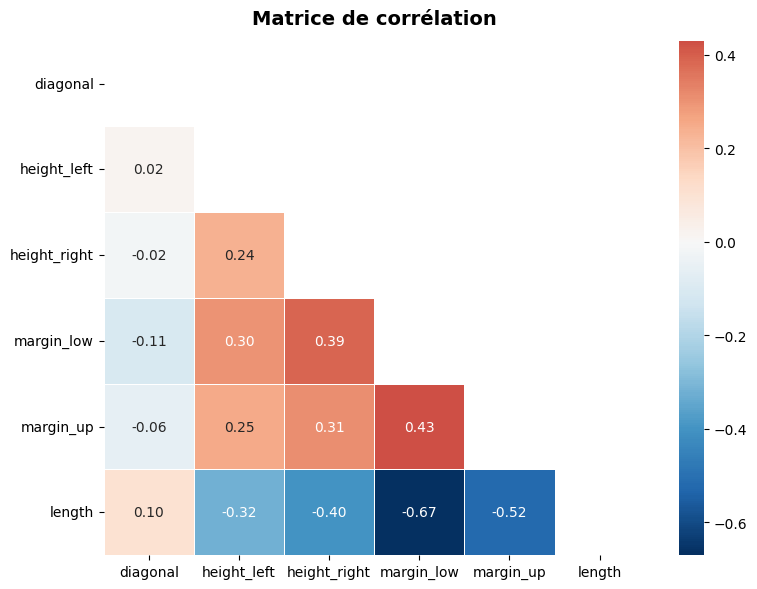

In [7]:
heatmap_corr(df)

In [8]:
FEATURE = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
df['is_fake'] = ~df['is_genuine']

X = df[FEATURE]
y = df['is_fake']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

In [10]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scalled = scaler.transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [11]:
imputer = KNNImputer(n_neighbors=5)
X_train_clean = imputer.fit_transform(X_train_scalled)
X_test_clean = imputer.transform(X_test_scalled)

X_train_clean = pd.DataFrame(X_train_clean, columns=X_train.columns, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_clean, columns=X_test.columns, index=X_test.index)

print(f"NaN train : \n{X_train_clean.isna().sum()}")
print(f"\nNaN test : \n{X_test_clean.isna().sum()}")

NaN train : 
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

NaN test : 
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64


In [12]:
df_train = pd.concat([X_train_clean, y_train], axis=1)
print("Mean", df_train.groupby('is_fake').mean())
print("\nStd", df_train.groupby('is_fake').std())

Mean          diagonal  height_left  height_right  margin_low  margin_up    length
is_fake                                                                      
False    0.113347    -0.260171     -0.327001   -0.558108  -0.427495  0.600734
True    -0.226695     0.520341      0.654002    1.103991   0.854991 -1.201469

Std          diagonal  height_left  height_right  margin_low  margin_up    length
is_fake                                                                      
False    0.988035     1.011631      0.912151    0.478907   0.803787  0.406361
True     0.987607     0.742300      0.835590    0.818190   0.783894  0.711427


In [13]:
for column in df_train.drop(columns='is_fake'):
    fig = box(df_train, x='is_fake', y=column, titre=column)
    fig.show()

## Synthèse de l'exploration

**Dataset** : 1500 billets (1000 vrais, 500 faux), 6 variables géométriques. Aucun doublon.

**Valeurs manquantes** : 37 valeurs manquantes sur `margin_low` (2.47%), réparties sans lien significatif avec le statut du billet (vérifié via crosstab). Imputées via `KNNImputer` (n_neighbors=5), après standardisation (`StandardScaler`) pour fiabiliser le calcul de distance entre billets. Le scaler et l'imputer sont fit uniquement sur le train, puis appliqués au test, pour éviter toute fuite de données.

**Variables discriminantes** : l'analyse des moyennes, des corrélations et des distributions (boxplots) converge vers le même classement :
- `length` et `margin_low` : très bonne séparation entre vrais et faux billets, quasi aucun chevauchement de distribution.
- `margin_up` et `height_right` : séparation correcte mais avec un certain chevauchement.
- `height_left` : séparation plus modérée.
- `diagonal` : très faible pouvoir discriminant, distributions quasi superposées entre les deux classes.

**Implication pour la modélisation** : `length` et `margin_low` devraient porter la majorité du pouvoir prédictif des modèles ; `diagonal` apportera probablement peu d'information.

In [14]:
joblib.dump(scaler, r"..\models\scaler.pkl")
joblib.dump(imputer, r"..\models\imputer.pkl")

['..\\models\\imputer.pkl']

In [15]:
X_train_clean.to_pickle(r"..\data\processed\X_train_clean.pkl")
X_test_clean.to_pickle(r"..\data\processed\X_test_clean.pkl")
y_train.to_pickle(r"..\data\processed\y_train.pkl")
y_test.to_pickle(r"..\data\processed\y_test.pkl")